1. Data Understanding

In [1]:
!pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


In [3]:
df = pd.read_csv('bitcoin.csv', sep=';')
# Ganti 'v' dengan '/' di kolom 'Date' untuk memperbaiki format yang tidak standar
df['Date'] = df['Date'].str.replace('v', '/', regex=False)
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)
df.head(10)

,Date,Open,High,Low,Close,Volume,MarketCap
0,2017-11-22,8077.95,8302.26,8075.47,8253.55,3633530000,134851000000
1,2017-11-21,8205.74,8348.66,7762.71,8071.26,4277610000,136967000000
2,2017-11-20,8039.07,8336.86,7949.36,8200.64,3488450000,134167000000
3,2017-11-19,7766.03,8101.91,7694.10,8036.49,3149320000,129595000000
4,2017-11-18,7697.21,7884.99,7463.44,7790.15,3667190000,128425000000
5,2017-11-17,7853.57,8004.59,7561.09,7708.99,4651670000,131026000000
6,2017-11-16,7323.24,7967.38,7176.58,7871.69,5123810000,122164000000
7,2017-11-15,6634.76,7342.25,6634.76,7315.54,4200880000,110667000000
8,2017-11-14,6561.48,6764.98,6461.75,6635.75,3197110000,109434000000
9,2017-11-13,5938.25,6811.19,5844.29,6559.49,6263250000,99029000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670 entries, 0 to 1669
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1670 non-null   datetime64[ns]
 1   Open       1670 non-null   float64       
 2   High       1670 non-null   float64       
 3   Low        1670 non-null   float64       
 4   Close      1670 non-null   float64       
 5   Volume     1670 non-null   int64         
 6   MarketCap  1670 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 91.5 KB


In [5]:
df.describe()

,Date,Open,High,Low,Close,Volume,MarketCap
count,1670,1670.000000,1670.000000,1670.000000,1670.000000,1.670000e+03,1.670000e+03
mean,2015-08-10 12:00:00,879.885383,906.418251,856.323287,884.715689,2.763772e+08,1.369657e+10
min,2013-04-28 00:00:00,68.500000,74.560000,65.530000,68.430000,0.000000e+00,7.792550e+08
25%,2014-06-19 06:00:00,265.492500,270.957500,261.037500,265.665000,1.535280e+07,3.775548e+09
50%,2015-08-10 12:00:00,454.855000,460.380000,446.500000,455.045000,3.858105e+07,6.601560e+09
75%,2016-09-30 18:00:00,759.920000,774.775000,739.362500,761.160000,9.893298e+07,1.074598e+10
max,2017-11-22 00:00:00,8205.740000,8348.660000,8075.470000,8253.550000,8.957350e+09,1.369670e+11
std,NaN,1260.770460,1308.731772,1223.859194,1273.816150,7.083169e+08,2.117795e+10


2. Data Preprocessing

In [6]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
MarketCap,0


In [7]:
# Hapus missing value yang mungkin muncul setelah penambahan fitur lag
df = df.dropna()

In [8]:
# Urutkan DataFrame berdasarkan tanggal untuk memastikan Moving Average yang benar
# Check if 'Date' is already the index name, if so, reset it
if 'Date' not in df.columns and df.index.name == 'Date':
    df = df.reset_index()

df = df.sort_values(by='Date')

# Set 'Date' sebagai indeks untuk memudahkan manipulasi time series
df = df.set_index('Date')

# Buat fitur lag untuk 'Close' (sudah ada)
df['Close_next'] = df['Close'].shift(-1)
df['Close_lag1'] = df['Close'].shift(1)
df['Close_lag2'] = df['Close'].shift(2)
df['Close_lag3'] = df['Close'].shift(3)

# Tambahkan lebih banyak fitur lag untuk kolom lain
df['Open_lag1'] = df['Open'].shift(1)
df['High_lag1'] = df['High'].shift(1)
df['Low_lag1'] = df['Low'].shift(1)
df['Volume_lag1'] = df['Volume'].shift(1)
df['MarketCap_lag1'] = df['MarketCap'].shift(1)

# Buat fitur-fitur berbasis waktu (sudah ada)
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['year'] = df.index.year
df['day_of_year'] = df.index.dayofyear # Tambahkan hari dalam setahun

# Buat fitur Moving Average (MA) dan Rolling Standard Deviation (RSD)
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_14'] = df['Close'].rolling(window=14).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()
df['MA_60'] = df['Close'].rolling(window=60).mean()

df['RSD_7'] = df['Close'].rolling(window=7).std()
df['RSD_14'] = df['Close'].rolling(window=14).std()

# Isi nilai NaN yang muncul akibat rolling window (Moving Average dan RSD) dengan forward fill
df = df.ffill()

# Hapus missing value yang mungkin tersisa setelah penambahan fitur lag dan MA/RSD
df = df.dropna()

df.head()

,Open,High,Low,Close,Volume,MarketCap,Close_next,Close_lag1,Close_lag2,Close_lag3,...,day_of_week,month,year,day_of_year,MA_7,MA_14,MA_30,MA_60,RSD_7,RSD_14
Date,,,,,,,,,,,,,,,,,,,,,
2013-06-26,103.33,105.49,102.79,104.00,0,1171050000,101.44,103.95,102.74,107.60,...,2,6,2013,177,106.605714,104.790714,112.141667,116.378167,2.988432,3.717655
2013-06-27,104.00,104.00,101.10,101.44,0,1179110000,94.65,104.00,103.95,102.74,...,3,6,2013,178,105.361429,104.607857,111.223000,115.832000,3.078671,3.821059
2013-06-28,101.74,101.74,92.33,94.65,0,1153880000,94.99,101.44,104.00,103.95,...,4,6,2013,179,103.240000,104.227143,109.968000,115.000500,4.527196,4.519352
2013-06-29,94.66,99.99,93.00,94.99,0,1074010000,96.61,94.65,101.44,104.00,...,5,6,2013,180,101.338571,103.870000,108.841000,114.267000,4.832596,5.046742
2013-06-30,95.00,98.12,94.22,96.61,0,1078260000,88.05,94.99,94.65,101.44,...,6,6,2013,181,99.768571,103.662857,107.761333,113.927333,4.203639,5.292971


3. Exploratory Data Analysis (EDA)

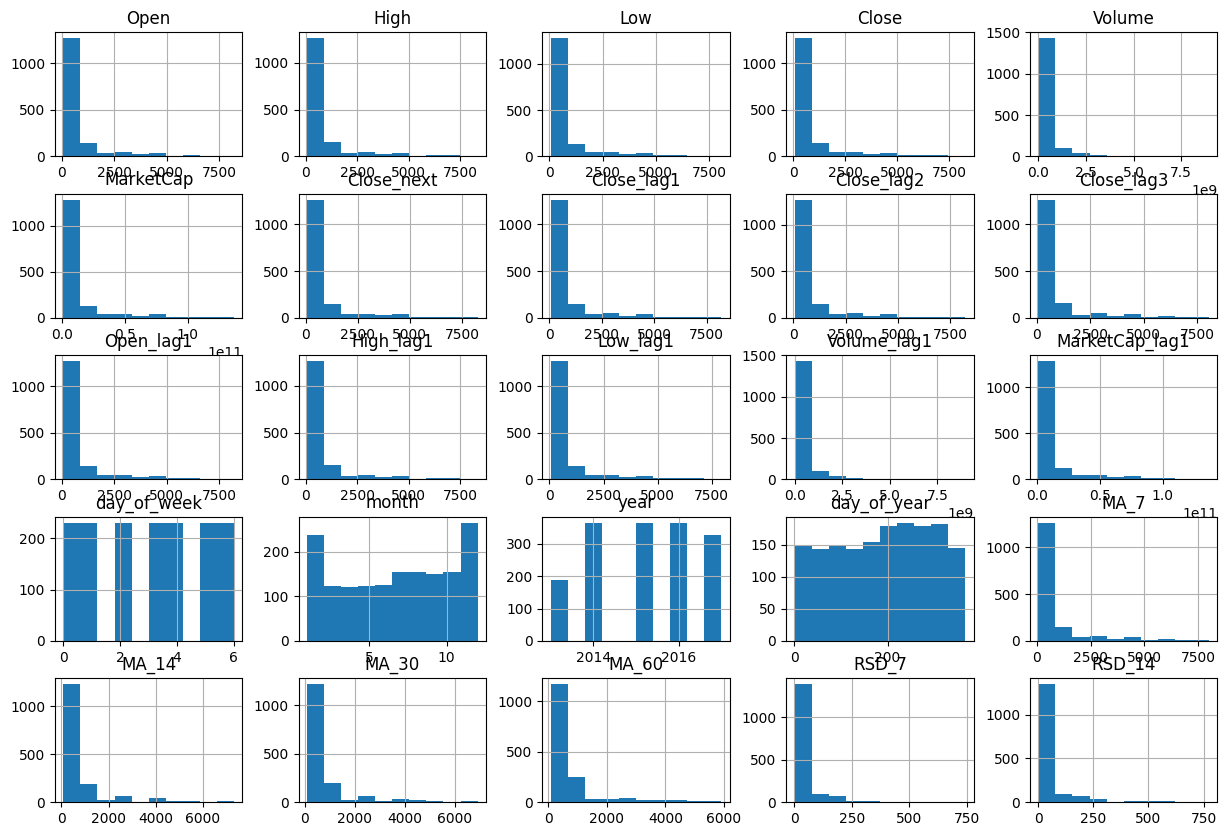

In [9]:
df.hist(figsize=(15, 10))
plt.show()

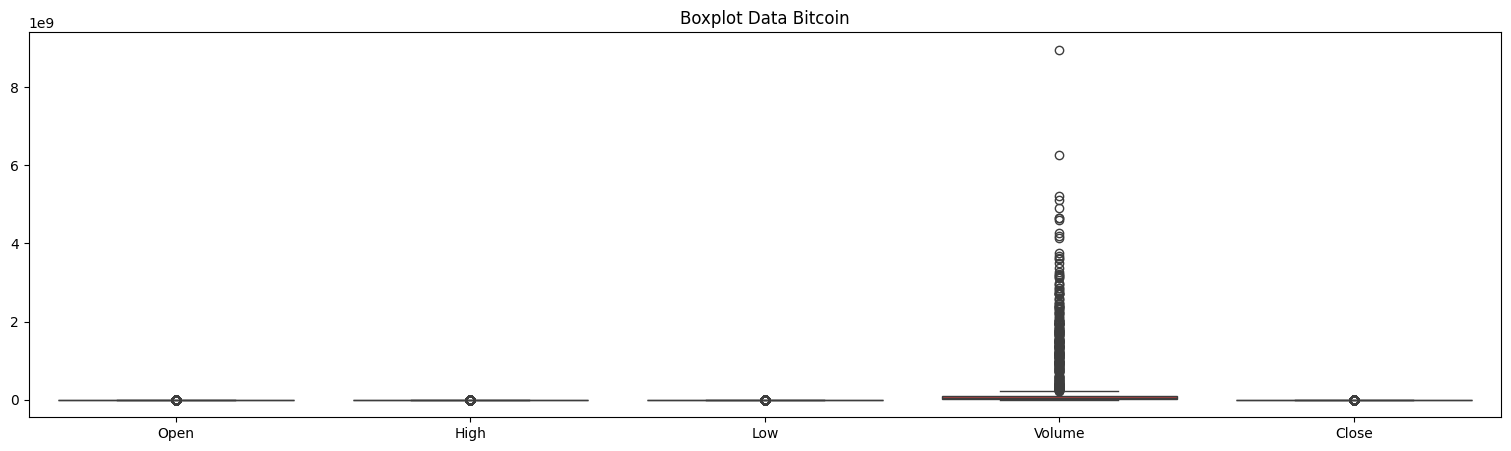

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(19,5))
sns.boxplot(data=df[['Open', 'High', 'Low', 'Volume', 'Close']])
plt.title('Boxplot Data Bitcoin')
plt.show()

In [11]:
Q1 = df[['Open','High','Low','Volume','Close']].quantile(0.25)
Q3 = df[['Open','High','Low','Volume','Close']].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[['Open','High','Low','Volume','Close']] < (Q1 - 1.5 * IQR)) |
          (df[['Open','High','Low','Volume','Close']] > (Q3 + 1.5 * IQR))).any(axis=1)]

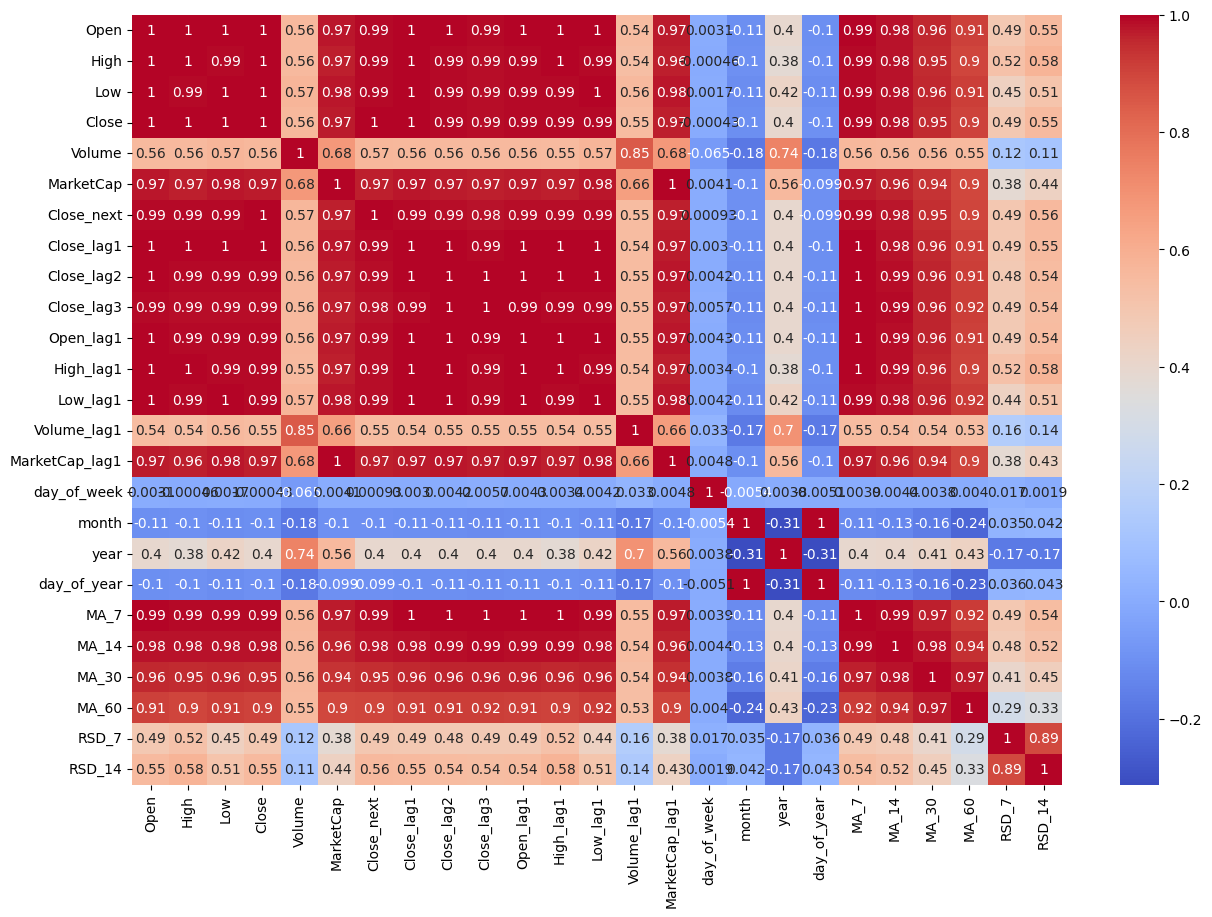

In [12]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

4. Data Spliting

In [13]:
from sklearn.model_selection import train_test_split

# Redefine features (X) to the original 12 features that yielded higher R2
X = df[['Open', 'High', 'Low', 'Volume', 'Close_lag1', 'Close_lag2', 'Close_lag3',
        'day_of_week', 'month', 'year', 'MarketCap', 'MarketCap_lag1']]
y = df['Close_next']

# For time series data, we should use chronological splitting to avoid data leakage
splits = {}

# 90:10 split
split_index_90_10 = int(len(df) * 0.9)
X_train_90_10, X_test_90_10 = X.iloc[:split_index_90_10], X.iloc[split_index_90_10:]
y_train_90_10, y_test_90_10 = y.iloc[:split_index_90_10], y.iloc[split_index_90_10:]
splits["chronological_90_10"] = (X_train_90_10, X_test_90_10, y_train_90_10, y_test_90_10)

# 80:20 split
split_index_80_20 = int(len(df) * 0.8)
X_train_80_20, X_test_80_20 = X.iloc[:split_index_80_20], X.iloc[split_index_80_20:]
y_train_80_20, y_test_80_20 = y.iloc[:split_index_80_20], y.iloc[split_index_80_20:]
splits["chronological_80_20"] = (X_train_80_20, X_test_80_20, y_train_80_20, y_test_80_20)

# 70:30 split
split_index_70_30 = int(len(df) * 0.7)
X_train_70_30, X_test_70_30 = X.iloc[:split_index_70_30], X.iloc[split_index_70_30:]
y_train_70_30, y_test_70_30 = y.iloc[:split_index_70_30], y.iloc[split_index_70_30:]
splits["chronological_70_30"] = (X_train_70_30, X_test_70_30, y_train_70_30, y_test_70_30)

print(f"X_train shape (90:10): {X_train_90_10.shape}, y_train shape (90:10): {y_train_90_10.shape}")
print(f"X_test shape (90:10): {X_test_90_10.shape}, y_test shape (90:10): {y_test_90_10.shape}\n")

print(f"X_train shape (80:20): {X_train_80_20.shape}, y_train shape (80:20): {y_train_80_20.shape}")
print(f"X_test shape (80:20): {X_test_80_20.shape}, y_test shape (80:20): {y_test_80_20.shape}\n")

print(f"X_train shape (70:30): {X_train_70_30.shape}, y_train shape (70:30): {y_train_70_30.shape}")
print(f"X_test shape (70:30): {X_test_70_30.shape}, y_test shape (70:30): {y_test_70_30.shape}")

X_train shape (90:10): (1201, 12), y_train shape (90:10): (1201,)
X_test shape (90:10): (134, 12), y_test shape (90:10): (134,)

X_train shape (80:20): (1068, 12), y_train shape (80:20): (1068,)
X_test shape (80:20): (267, 12), y_test shape (80:20): (267,)

X_train shape (70:30): (934, 12), y_train shape (70:30): (934,)
X_test shape (70:30): (401, 12), y_test shape (70:30): (401,)


In [14]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return mae, mse, rmse, r2

results_enhanced = []

for name, (X_train_split, X_test_split, y_train_split, y_test_split) in splits.items():

    # XGBoost
    xgb_model = XGBRegressor()
    xgb_model.fit(X_train_split, y_train_split)
    pred_xgb_enhanced = xgb_model.predict(X_test_split)
    mae, mse, rmse, r2 = evaluate(y_test_split, pred_xgb_enhanced)
    results_enhanced.append(["XGBoost (Enhanced Features)", name, mae, mse, rmse, r2])

    # LightGBM
    lgbm_model = LGBMRegressor()
    lgbm_model.fit(X_train_split, y_train_split)
    pred_lgbm_enhanced = lgbm_model.predict(X_test_split)
    mae, mse, rmse, r2 = evaluate(y_test_split, pred_lgbm_enhanced)
    results_enhanced.append(["LightGBM (Enhanced Features)", name, mae, mse, rmse, r2])

    # CatBoost
    cat_model = CatBoostRegressor(verbose=0)
    cat_model.fit(X_train_split, y_train_split)
    pred_cat_enhanced = cat_model.predict(X_test_split)
    mae, mse, rmse, r2 = evaluate(y_test_split, pred_cat_enhanced)
    results_enhanced.append(["CatBoost (Enhanced Features)", name, mae, mse, rmse, r2])

results_enhanced_df = pd.DataFrame(results_enhanced, columns=["Model", "Split", "MAE", "MSE", "RMSE", "R2"])
print("Performance with Enhanced Features:")
results_enhanced_df

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000310 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2320
[LightGBM] [Info] Number of data points in the train set: 1201, number of used features: 12
[LightGBM] [Info] Start training from score 411.965029
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000324 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2320
[LightGBM] [Info] Number of data points in the train set: 1068, number of used features: 12
[LightGBM] [Info] Start training from score 386.298792
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000204 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2316
[LightGBM] [Info] Number of data points in the train s

,Model,Split,MAE,MSE,RMSE,R2
0,XGBoost (Enhanced Features),chronological_90_10,82.448714,14333.609177,119.723052,0.510389
1,LightGBM (Enhanced Features),chronological_90_10,65.448926,10733.429498,103.602266,0.633364
2,CatBoost (Enhanced Features),chronological_90_10,142.064299,38810.168986,197.002967,-0.325689
3,XGBoost (Enhanced Features),chronological_80_20,42.119320,4933.574670,70.239410,0.853698
4,LightGBM (Enhanced Features),chronological_80_20,55.462358,8773.877016,93.668976,0.739817
5,CatBoost (Enhanced Features),chronological_80_20,95.973740,22937.386790,151.450939,0.319808
6,XGBoost (Enhanced Features),chronological_70_30,38.269902,5389.309075,73.411914,0.884865
7,LightGBM (Enhanced Features),chronological_70_30,36.135420,5075.949420,71.245698,0.891560
8,CatBoost (Enhanced Features),chronological_70_30,77.992431,18981.657525,137.773936,0.594484


5. Model Building

In [15]:
results = []

for name, (X_train, X_test, y_train, y_test) in splits.items():

    # XGBoost
    xgb = XGBRegressor()
    xgb.fit(X_train, y_train)
    pred_xgb = xgb.predict(X_test)
    results.append(["XGBoost", name, *evaluate(y_test, pred_xgb)])

    # LightGBM
    lgbm = LGBMRegressor()
    lgbm.fit(X_train, y_train)
    pred_lgbm = lgbm.predict(X_test)
    results.append(["LightGBM", name, *evaluate(y_test, pred_lgbm)])

    # CatBoost
    cat = CatBoostRegressor(verbose=0)
    cat.fit(X_train, y_train)
    pred_cat = cat.predict(X_test)
    results.append(["CatBoost", name, *evaluate(y_test, pred_cat)])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000086 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2320
[LightGBM] [Info] Number of data points in the train set: 1201, number of used features: 12
[LightGBM] [Info] Start training from score 411.965029
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000247 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2320
[LightGBM] [Info] Number of data points in the train set: 1068, number of used features: 12
[LightGBM] [Info] Start training from score 386.298792
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000261 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2316
[LightGBM] [Info] Number of data points in the train s

In [16]:
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "Split", "MAE", "MSE", "RMSE", "R2"])
results_df

,Model,Split,MAE,MSE,RMSE,R2
0,XGBoost,chronological_90_10,82.448714,14333.609177,119.723052,0.510389
1,LightGBM,chronological_90_10,65.448926,10733.429498,103.602266,0.633364
2,CatBoost,chronological_90_10,142.064299,38810.168986,197.002967,-0.325689
3,XGBoost,chronological_80_20,42.119320,4933.574670,70.239410,0.853698
4,LightGBM,chronological_80_20,55.462358,8773.877016,93.668976,0.739817
5,CatBoost,chronological_80_20,95.973740,22937.386790,151.450939,0.319808
6,XGBoost,chronological_70_30,38.269902,5389.309075,73.411914,0.884865
7,LightGBM,chronological_70_30,36.135420,5075.949420,71.245698,0.891560
8,CatBoost,chronological_70_30,77.992431,18981.657525,137.773936,0.594484


6. Hyperparameter Tunning

In [17]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

grid = GridSearchCV(XGBRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
pred = best_model.predict(X_test)

evaluate(y_test, pred)

(33.37666271028971,
 4088.4115390003244,
 np.float64(63.940687664431046),
 0.9126569803963948)

### LightGBM Hyperparameter Tuning

In [18]:
from lightgbm import LGBMRegressor # Added import to fix NameError
from sklearn.model_selection import GridSearchCV # Added import for GridSearchCV

# Parameter yang diuji
param_grid_lgb = {
    'n_estimators': [100, 200, 300, 500], # Increased range
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # Increased range
    'max_depth': [3, 5, 7, 9] # Increased range
}

# Model dasar
lgb = LGBMRegressor(random_state=42) # Added random_state for reproducibility

# Grid Search
grid_lgb = GridSearchCV(
    estimator=lgb,
    param_grid=param_grid_lgb,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

# As per the current kernel state, X_train and y_train refer to the chronological_70_30 split
# which yielded the highest R2 for LightGBM before tuning.
grid_lgb.fit(X_train, y_train)

# Hasil terbaik
print("Best Parameter LightGBM:", grid_lgb.best_params_)

# Model terbaik
best_lgb = grid_lgb.best_estimator_

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000162 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2316
[LightGBM] [Info] Number of data points in the train set: 934, number of used features: 12
[LightGBM] [Info] Start training from score 380.782912
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

### LightGBM Hyperparameter Tuning (Fine-grained)

In [19]:
param_grid_lgb_fine = {
    'n_estimators': [90, 100, 110, 120],
    'learning_rate': [0.08, 0.1, 0.12, 0.15],
    'max_depth': [4, 5, 6]
}

lgb_fine = LGBMRegressor(random_state=42, n_jobs=-1)

grid_lgb_fine = GridSearchCV(
    estimator=lgb_fine,
    param_grid=param_grid_lgb_fine,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_lgb_fine.fit(X_train, y_train)

print("Best Parameter LightGBM (Fine-tuned):", grid_lgb_fine.best_params_)

best_lgb_fine = grid_lgb_fine.best_estimator_


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000200 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2316
[LightGBM] [Info] Number of data points in the train set: 934, number of used features: 12
[LightGBM] [Info] Start training from score 380.782912
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

### Evaluate Fine-tuned LightGBM Model

In [20]:
# Make predictions with the fine-tuned LightGBM model
pred_best_lgbm_fine = best_lgb_fine.predict(X_test)

# Evaluate the fine-tuned model's performance
mae_tuned_fine, mse_tuned_fine, rmse_tuned_fine, r2_tuned_fine = evaluate(y_test, pred_best_lgbm_fine)

print(f"Fine-tuned LightGBM Model Performance (on chronological_70_30 split):")
print(f"MAE: {mae_tuned_fine:.4f}")
print(f"MSE: {mse_tuned_fine:.4f}")
print(f"RMSE: {rmse_tuned_fine:.4f}")
print(f"R2: {r2_tuned_fine:.4f}")


Fine-tuned LightGBM Model Performance (on chronological_70_30 split):
MAE: 35.5156
MSE: 5469.8698
RMSE: 73.9586
R2: 0.8831


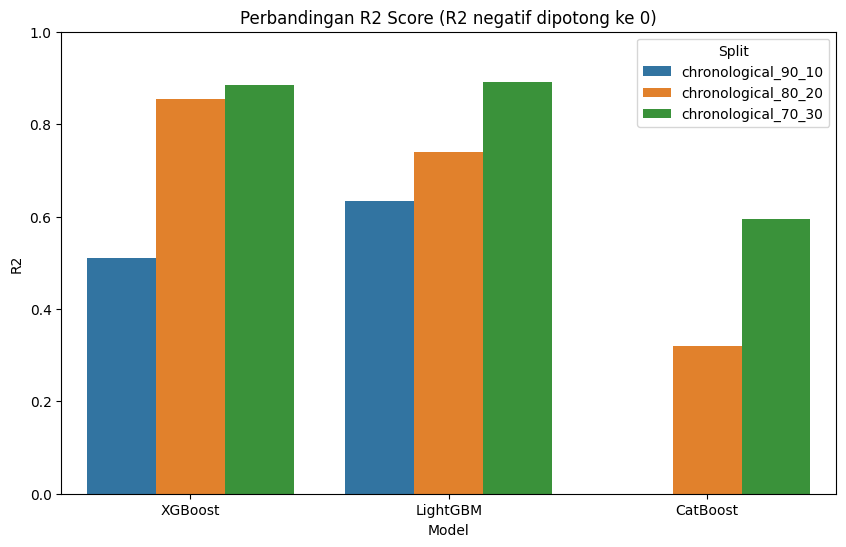

In [21]:
plt.figure(figsize=(10,6))
# Clip R2 values below 0 to 0 for better visualization, as negative R2 implies worse than baseline
results_df_plot = results_df.copy()
results_df_plot['R2'] = results_df_plot['R2'].apply(lambda x: max(0, x))

sns.barplot(data=results_df_plot, x="Model", y="R2", hue="Split")
plt.title("Perbandingan R2 Score (R2 negatif dipotong ke 0)")
plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for R2
plt.show()

In [22]:
import pandas as pd # Added for robustness

scores = []

for name, (X_train, X_test, y_train, y_test) in splits.items():

    # XGBoost
    xgb = XGBRegressor()
    xgb.fit(X_train, y_train)
    scores.append([
        "XGBoost",
        name,
        xgb.score(X_train, y_train),
        xgb.score(X_test, y_test)
    ])

    # LightGBM
    lgbm = LGBMRegressor()
    lgbm.fit(X_train, y_train)
    scores.append([
        "LightGBM",
        name,
        lgbm.score(X_train, y_train),
        lgbm.score(X_test, y_test)
    ])

    # CatBoost
    cat = CatBoostRegressor(verbose=0)
    cat.fit(X_train, y_train)
    scores.append([
        "CatBoost",
        name,
        cat.score(X_train, y_train),
        cat.score(X_test, y_test)
    ])

# Jadikan DataFrame
score_df = pd.DataFrame(scores, columns=["Model", "Split", "Train R2", "Test R2"])
score_df

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000252 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2320
[LightGBM] [Info] Number of data points in the train set: 1201, number of used features: 12
[LightGBM] [Info] Start training from score 411.965029
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000260 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2320
[LightGBM] [Info] Number of data points in the train set: 1068, number of used features: 12
[LightGBM] [Info] Start training from score 386.298792
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000228 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2316
[LightGBM] [Info] Number of data points in the train set: 934, number of used features: 12
[LightGBM] [Info] Start tra

,Model,Split,Train R2,Test R2
0,XGBoost,chronological_90_10,0.999919,0.510389
1,LightGBM,chronological_90_10,0.993152,0.633364
2,CatBoost,chronological_90_10,0.997990,-0.325689
3,XGBoost,chronological_80_20,0.999920,0.853698
4,LightGBM,chronological_80_20,0.990854,0.739817
5,CatBoost,chronological_80_20,0.997938,0.319808
6,XGBoost,chronological_70_30,0.999951,0.884865
7,LightGBM,chronological_70_30,0.991259,0.891560
8,CatBoost,chronological_70_30,0.997982,0.594484


Evaluasi Hasil

In [23]:
best_model_row = results_df.sort_values(by="R2", ascending=False).iloc[0]
best_model_row

,7
Model,LightGBM
Split,chronological_70_30
MAE,36.13542
MSE,5075.94942
RMSE,71.245698
R2,0.89156


In [24]:
from sklearn.model_selection import train_test_split # Added for robustness
from lightgbm import LGBMRegressor # Added for robustness

# The X_train, X_test, y_train, y_test from the chronological split are already available
# and were used for grid_lgb.fit(). Re-splitting is unnecessary and incorrect for time series.

# Re-initialize the best LightGBM model with its best parameters
best_model_params = grid_lgb.best_params_
best_model = LGBMRegressor(**best_model_params)
best_model.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000155 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2316
[LightGBM] [Info] Number of data points in the train set: 934, number of used features: 12
[LightGBM] [Info] Start training from score 380.782912
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

LGBMRegressor(learning_rate=0.2, max_depth=3)

In [25]:
# Make predictions with the best LightGBM model on the test set
pred_best_lgbm = best_model.predict(X_test)

# Evaluate the best model's performance
mae_tuned, mse_tuned, rmse_tuned, r2_tuned = evaluate(y_test, pred_best_lgbm)

# The X_test, y_test in the kernel state are from the chronological_70_30 split
print(f"Tuned LightGBM Model Performance (on chronological_70_30 split):")
print(f"MAE: {mae_tuned:.4f}")
print(f"MSE: {mse_tuned:.4f}")
print(f"RMSE: {rmse_tuned:.4f}")
print(f"R2: {r2_tuned:.4f}")

Tuned LightGBM Model Performance (on chronological_70_30 split):
MAE: 34.9573
MSE: 4545.9568
RMSE: 67.4237
R2: 0.9029


In [26]:
from lightgbm import LGBMRegressor

final_model = LGBMRegressor()
final_model.fit(X, y)

booster = final_model.booster_
booster.save_model('model_bitcoin.txt')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2321
[LightGBM] [Info] Number of data points in the train set: 1335, number of used features: 12
[LightGBM] [Info] Start training from score 459.765153


In [28]:
from google.colab import files
files.download('model_bitcoin.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 7. Inference

After training and tuning, the `final_model` is ready to make predictions on new data. It's crucial that the new data is preprocessed in the same way as the training data, ensuring it has the same features and format.

In [27]:
# Make predictions on the X_test dataset using the final_model
# (Note: X_test here refers to the test set from the 70:30 chronological split, as used in previous tuning steps)
inference_predictions = final_model.predict(X_test)

# Create a DataFrame to compare actual values (y_test) with predictions
inference_results = pd.DataFrame({
    'Actual_Close_Next': y_test,
    'Predicted_Close_Next': inference_predictions
})

# Display the first few rows of the inference results
print("Inference Results (Actual vs. Predicted Close Prices):")
display(inference_results.head())

Inference Results (Actual vs. Predicted Close Prices):


,Actual_Close_Next,Predicted_Close_Next
Date,,
2016-01-17,387.17,385.587705
2016-01-18,380.15,386.850980
2016-01-19,420.23,392.030475
2016-01-20,410.26,400.696210
2016-01-21,382.49,393.062241
